# Giai đoạn 2 — Huấn luyện & Đánh giá theo nhóm tấn công (CIC-DDoS 2019)

**Input:** Danh sách N đặc trưng FAMS từ `fams_features.json` (output Phase 1)  
**Dataset:** CIC-DDoS 2019 (17 file Parquet)  
**Models:** KNN · Random Forest · XGBoost  

## Phân nhóm tấn công — Taxonomy CIC-DDoS 2019

```
DDoS Attacks
├── Reflection Attacks (khuếch đại qua máy chủ trung gian)
│   ├── G1 — Application Protocol: MSSQL · DNS · LDAP · NetBIOS · SNMP · Portmap
│   └── G2 — Volume UDP:           NTP · TFTP
└── Exploitation Attacks (tấn công trực tiếp)
    └── G3 — Direct Flood:         Syn · UDP · UDPLag · WebDDoS
```

## Thí nghiệm Leave-One-Group-Out

| Thí nghiệm | Train | Test (chưa thấy) | Câu hỏi nghiên cứu |
|-----------|-------|-----------------|--------------------|
| Exp 1 | G1 + Benign | G2 + G3 + Benign | Reflection/App → Reflection/Vol + Exploitation? |
| Exp 2 | G2 + Benign | G1 + G3 + Benign | Reflection/Vol → Reflection/App + Exploitation? |
| Exp 3 ⚠ | G3 + Benign | G1 + G2 + Benign | Exploitation → toàn bộ Reflection? |

## Ghi chú thiết kế
- **RobustScaler** thay MinMaxScaler — bền với outlier network traffic
- **`class_weight='balanced'`** thay SMOTE — không tạo mẫu tổng hợp giả
- **KNN** không hỗ trợ `class_weight` — chạy không có cân bằng lớp, ghi nhận giới hạn
- **Optuna objective = F2** nhất quán cả 3 thí nghiệm — ưu tiên Recall trong IDS
- **CV scoring = F2** — nhất quán với objective
- **Benign split** random 70/30 một lần, dùng chung — tránh rò rỉ Benign
- ⚠ **Exp 3**: Syn và WebDDoS rất ít mẫu — giới hạn thực tế của dataset

In [1]:
import os, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import RobustScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, fbeta_score, roc_auc_score,
    roc_curve, confusion_matrix, classification_report
)
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
SEED = 42
np.random.seed(SEED)
print('Imports OK.')

Imports OK.


In [2]:
# ============================================================
# CẤU HÌNH
# ============================================================

CIC_DDOS2019_DIR  = 'data/ddos2019/'
FAMS_FEATURES_FILE = 'fams_features.json'  # output từ Phase 1

OPTUNA_TRIALS    = 30
OPTUNA_SUBSAMPLE = 50_000   # rows cho mỗi Optuna trial
CV_FOLDS         = 5
CV_CAP           = 100_000  # cap rows cho CV
SEED             = 42

# Chuẩn hoá nhãn CIC-DDoS 2019
def normalise_label(lbl: str) -> str:
    lbl = str(lbl).strip()
    mapping = {
        'DrDoS_DNS':    'DNS',
        'DrDoS_LDAP':   'LDAP',
        'DrDoS_MSSQL':  'MSSQL',
        'DrDoS_NetBIOS':'NetBIOS',
        'DrDoS_NTP':    'NTP',
        'DrDoS_SNMP':   'SNMP',
        'DrDoS_SSDP':   'SSDP',
        'DrDoS_UDP':    'UDP',
        'UDP-lag':      'UDPLag',
    }
    return mapping.get(lbl, lbl)

# Phân nhóm tấn công theo taxonomy CIC-DDoS 2019
ATTACK_GROUPS = {
    'G1_Reflection_Application': ['MSSQL', 'DNS', 'LDAP', 'NetBIOS', 'SNMP', 'Portmap'],
    'G2_Reflection_Volume':      ['NTP', 'TFTP'],
    'G3_Exploitation':           ['Syn', 'UDP', 'UDPLag', 'WebDDoS'],
}
LABEL_TO_GROUP = {lbl: grp for grp, lbls in ATTACK_GROUPS.items() for lbl in lbls}

COLORS = {'KNN': 'steelblue', 'RF': 'darkorange', 'XGB': 'forestgreen'}

# Nạp FAMS features từ Phase 1
with open(FAMS_FEATURES_FILE) as fp:
    FAMS_FEATURES = json.load(fp)
print(f'FAMS features từ Phase 1 ({len(FAMS_FEATURES)}): {FAMS_FEATURES}')

FAMS features từ Phase 1 (18): ['Fwd Packet Length Mean', 'Fwd Packet Length Max', 'Fwd Packets Length Total', 'Fwd Seg Size Min', 'Flow IAT Min', 'Fwd Packet Length Std', 'Subflow Bwd Bytes', 'Packet Length Max', 'Init Bwd Win Bytes', 'Packet Length Std', 'Subflow Fwd Bytes', 'Fwd Header Length', 'Flow Packets/s', 'Bwd Packet Length Max', 'Bwd Packets Length Total', 'Avg Fwd Segment Size', 'Subflow Fwd Packets', 'Bwd Packet Length Std']


## ① Nạp & Chuẩn hoá nhãn — CIC-DDoS 2019

In [3]:
pq_files = sorted([
    os.path.join(CIC_DDOS2019_DIR, f)
    for f in os.listdir(CIC_DDOS2019_DIR) if f.endswith('.parquet')
])
print(f'Tìm thấy {len(pq_files)} file Parquet')

frames = []
for fpath in pq_files:
    df_tmp = pd.read_parquet(fpath)
    df_tmp.columns = df_tmp.columns.str.strip()
    df_tmp['Label'] = df_tmp['Label'].astype(str).str.strip().map(normalise_label)

    # Chỉ giữ FAMS features + Label
    keep = [c for c in FAMS_FEATURES if c in df_tmp.columns] + ['Label']
    frames.append(df_tmp[keep])

df_raw = pd.concat(frames, ignore_index=True)
print(f'\nDDoS 2019 đã nạp: {len(df_raw):,} dòng')
print('Phân phối nhãn (sau chuẩn hoá):')
print(df_raw['Label'].value_counts())

# Kiểm tra FAMS features có đủ không
missing = [f for f in FAMS_FEATURES if f not in df_raw.columns]
if missing:
    print(f'\n[WARNING] Đặc trưng vắng mặt trong DDoS 2019: {missing}')
else:
    print(f'\nTất cả {len(FAMS_FEATURES)} FAMS features có trong DDoS 2019. OK.')

Tìm thấy 17 file Parquet



DDoS 2019 đã nạp: 431,371 dòng
Phân phối nhãn (sau chuẩn hoá):
Label
NTP        121368
TFTP        98917
Benign      97831
Syn         49373
UDP         28510
MSSQL       14735
UDPLag       8927
DNS          3669
LDAP         3346
SNMP         2717
NetBIOS      1242
Portmap       685
WebDDoS        51
Name: count, dtype: int64

Tất cả 18 FAMS features có trong DDoS 2019. OK.


## ② Tiền xử lý
## ③ Mã hoá nhãn & Phân nhóm

In [4]:
feat_cols = [f for f in FAMS_FEATURES if f in df_raw.columns]
df = df_raw.copy()

# Ép kiểu, ±∞ → NaN, dropna, dedup
for col in feat_cols:
    if df[col].dtype == object:
        df[col] = pd.to_numeric(df[col], errors='coerce')
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
print(f'Sau tiền xử lý: {len(df):,} dòng')

# Mã hoá nhãn nhị phân
df['label_bin'] = (df['Label'].str.upper() != 'BENIGN').astype(int)

# Phân nhóm
df['Group'] = df['Label'].map(LABEL_TO_GROUP)

print('\nSố dòng theo nhóm:')
grp_counts = df.groupby('Group')['label_bin'].agg(['count', 'sum'])
grp_counts.columns = ['Tổng', 'Tấn công']
grp_counts['Benign'] = grp_counts['Tổng'] - grp_counts['Tấn công']
print(grp_counts.to_string())

print('\nSố dòng theo loại tấn công trong từng nhóm:')
for grp in ATTACK_GROUPS:
    sub = df[df['Group'] == grp]['Label'].value_counts()
    print(f'\n  {grp}:')
    print(sub.to_string())

Sau tiền xử lý: 388,505 dòng

Số dòng theo nhóm:
                             Tổng  Tấn công  Benign
Group                                              
G1_Reflection_Application   22839     22839       0
G2_Reflection_Volume       200705    200705       0
G3_Exploitation             77471     77471       0

Số dòng theo loại tấn công trong từng nhóm:

  G1_Reflection_Application:
Label
MSSQL      12227
DNS         3669
LDAP        2722
SNMP        2715
NetBIOS      833
Portmap      673

  G2_Reflection_Volume:
Label
NTP     113333
TFTP     87372

  G3_Exploitation:
Label
Syn        42746
UDP        26227
UDPLag      8447
WebDDoS       51


## ④ Phân nhóm tấn công
## ⑤ Phân chia Benign — 1 lần, dùng chung 3 thí nghiệm

Random split 70/30 (Benign chỉ 1 nhãn, không cần stratify).  
Cùng `ben_train` và `ben_test` được dùng trong cả 3 thí nghiệm → không có Benign trùng lặp.

In [5]:
benign_df = df[df['label_bin'] == 0].copy()
attack_df = df[df['label_bin'] == 1].copy()

# Random 70/30 — không cần stratify (chỉ 1 nhãn)
ben_train, ben_test = train_test_split(
    benign_df, test_size=0.30, random_state=SEED
)
print(f'Benign  : {len(benign_df):,} dòng')
print(f'ben_train: {len(ben_train):,} (70%)')
print(f'ben_test : {len(ben_test):,}  (30%)')

print('\nTấn công theo nhóm:')
for grp, attacks in ATTACK_GROUPS.items():
    n = len(attack_df[attack_df['Group'] == grp])
    low = [a for a in attacks if len(attack_df[attack_df['Label']==a]) < 200]
    warn = f'  ⚠ rất ít: {low}' if low else ''
    print(f'  {grp}: {n:,} dòng{warn}')

Benign  : 87,490 dòng
ben_train: 61,243 (70%)
ben_test : 26,247  (30%)

Tấn công theo nhóm:
  G1_Reflection_Application: 22,839 dòng
  G2_Reflection_Volume: 200,705 dòng
  G3_Exploitation: 77,471 dòng  ⚠ rất ít: ['WebDDoS']


## Experiment Engine

Mỗi thí nghiệm chạy qua:
1. **Tạo tập train/test** — ben_train/test + nhóm tấn công tương ứng
2. **RobustScaler** — fit trên train
3. **Optuna** — 30 trials, TPE sampler, **mục tiêu F2** (β=2, ưu tiên Recall)
4. **5-fold StratifiedKFold CV** — scoring F2, best params từ Optuna
5. **Huấn luyện** trên toàn bộ X_train
6. **Đánh giá** trên tập test chưa thấy: Accuracy · Precision · Recall · F1 · F2 · FNR · AUC

In [6]:
# ── Model registry ────────────────────────────────────────────────────────────
def build_model_registry(neg_count, pos_count):
    spw = neg_count / max(pos_count, 1)
    return {
        'KNN': {
            'note': 'Không hỗ trợ class_weight — chạy không cân bằng lớp',
            'param_space': lambda trial: {
                'n_neighbors': trial.suggest_int('n_neighbors', 1, 30),
                'weights':     trial.suggest_categorical('weights', ['uniform', 'distance']),
                'algorithm':   trial.suggest_categorical('algorithm', ['ball_tree', 'kd_tree', 'brute']),
            },
            'build': lambda p: KNeighborsClassifier(**p, n_jobs=-1),
        },
        'RF': {
            'note': 'class_weight=balanced',
            'param_space': lambda trial: {
                'n_estimators':      trial.suggest_int('n_estimators', 50, 300),
                'max_depth':         trial.suggest_int('max_depth', 5, 30),
                'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
                'max_features':      trial.suggest_categorical('max_features', ['sqrt', 'log2']),
            },
            'build': lambda p: RandomForestClassifier(
                **p, class_weight='balanced', n_jobs=-1, random_state=SEED),
        },
        'XGB': {
            'note': f'scale_pos_weight={spw:.2f}',
            'param_space': lambda trial: {
                'n_estimators':     trial.suggest_int('n_estimators', 50, 300),
                'max_depth':        trial.suggest_int('max_depth', 3, 12),
                'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
                'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
                'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
                'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            },
            'build': lambda p: XGBClassifier(
                **p, scale_pos_weight=spw,
                eval_metric='logloss', random_state=SEED, n_jobs=-1, verbosity=0),
        },
    }


def run_experiment(exp_name, train_group, test_groups):
    """Chạy 1 thí nghiệm leave-one-group-out."""
    print(f'\n{"="*65}')
    print(f'  {exp_name}')
    print(f'  Train: ben_train + {train_group}')
    print(f'  Test : ben_test  + {test_groups}')
    print(f'{"="*65}')

    tr_atk = attack_df[attack_df['Group'] == train_group]
    te_atk = attack_df[attack_df['Group'].isin(test_groups)]

    if len(tr_atk) < 10:
        print(f'[SKIP] Quá ít mẫu tấn công train: {len(tr_atk)}')
        return None

    train_df = pd.concat([ben_train, tr_atk], ignore_index=True)
    test_df  = pd.concat([ben_test,  te_atk], ignore_index=True)

    X_tr = train_df[feat_cols].values.astype(np.float32)
    y_tr = train_df['label_bin'].values
    X_te = test_df[feat_cols].values.astype(np.float32)
    y_te = test_df['label_bin'].values

    cnt_tr = Counter(y_tr)
    print(f'  Train: {len(X_tr):,} | Benign={cnt_tr[0]:,} Attack={cnt_tr[1]:,} | ratio={cnt_tr[0]/max(cnt_tr[1],1):.1f}:1')
    print(f'  Test : {len(X_te):,} | Benign={Counter(y_te)[0]:,} Attack={Counter(y_te)[1]:,}')

    # RobustScaler
    sc = RobustScaler()
    X_tr_sc = sc.fit_transform(X_tr)
    X_te_sc = sc.transform(X_te)

    registry = build_model_registry(cnt_tr[0], cnt_tr[1])

    # Subsample cho Optuna
    n_sub = min(len(X_tr_sc), OPTUNA_SUBSAMPLE)
    idx_sub = np.random.RandomState(SEED).choice(len(X_tr_sc), n_sub, replace=False)
    X_sub, y_sub = X_tr_sc[idx_sub], y_tr[idx_sub]
    X_opt_tr, X_opt_val, y_opt_tr, y_opt_val = train_test_split(
        X_sub, y_sub, test_size=0.20, random_state=SEED, stratify=y_sub
    )

    # Subsample cho CV
    n_cv = min(len(X_tr_sc), CV_CAP)
    idx_cv = np.random.RandomState(SEED).choice(len(X_tr_sc), n_cv, replace=False)
    X_cv, y_cv = X_tr_sc[idx_cv], y_tr[idx_cv]
    cv_splitter = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)

    exp_results = {}
    for mname, cfg in registry.items():
        print(f'\n  [{mname}] {cfg["note"]}')
        print(f'  Optuna {OPTUNA_TRIALS} trials ...', end=' ', flush=True)
        t0 = time.time()

        # Optuna — objective: F2
        def make_objective(cfg_inner, Xtr, ytr, Xval, yval):
            def objective(trial):
                m = cfg_inner['build'](cfg_inner['param_space'](trial))
                m.fit(Xtr, ytr)
                return fbeta_score(yval, m.predict(Xval), beta=2, zero_division=0)
            return objective

        study = optuna.create_study(
            direction='maximize',
            sampler=optuna.samplers.TPESampler(seed=SEED)
        )
        study.optimize(
            make_objective(cfg, X_opt_tr, y_opt_tr, X_opt_val, y_opt_val),
            n_trials=OPTUNA_TRIALS, show_progress_bar=False
        )
        print(f'best_F2_val={study.best_value:.4f} ({time.time()-t0:.1f}s)')

        # 5-fold CV — scoring F2
        cv_model = cfg['build'](study.best_params)
        from sklearn.metrics import make_scorer
        f2_scorer = make_scorer(fbeta_score, beta=2, zero_division=0)
        cv_scores = cross_val_score(
            cv_model, X_cv, y_cv, cv=cv_splitter, scoring=f2_scorer, n_jobs=-1
        )
        print(f'  5-fold CV F2: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

        # ── Huấn luyện final + đo thời gian ──────────────────────────────────
        final = cfg['build'](study.best_params)
        t_train_start = time.time()
        final.fit(X_tr_sc, y_tr)
        train_time_s = time.time() - t_train_start

        # ── Suy luận + đo thời gian per sample ───────────────────────────────
        y_pred  = final.predict(X_te_sc)
        y_proba = final.predict_proba(X_te_sc)[:, 1]

        # Đo inference time: lấy mẫu 5000 dòng, chạy 5 lần lấy trung bình
        N_INFER = min(5_000, len(X_te_sc))
        X_infer = X_te_sc[:N_INFER]
        t_infer = time.time()
        REPEATS = 5
        for _ in range(REPEATS):
            final.predict(X_infer)
        infer_ms_per_sample = (time.time() - t_infer) / REPEATS / N_INFER * 1_000

        print(f'  Train time: {train_time_s:.2f}s | Infer time: {infer_ms_per_sample:.4f} ms/sample')

        # ── Tính chỉ số phân loại ─────────────────────────────────────────────
        tn, fp, fn, tp = confusion_matrix(y_te, y_pred).ravel()
        fnr = fn / (fn + tp) if (fn + tp) > 0 else 0

        result = {
            'CV_F2_mean':         round(float(cv_scores.mean()), 4),
            'CV_F2_std':          round(float(cv_scores.std()),  4),
            '_cv_scores':         cv_scores,
            'Accuracy':           round(accuracy_score(y_te, y_pred), 4),
            'Precision':          round(precision_score(y_te, y_pred, zero_division=0), 4),
            'Recall':             round(recall_score(y_te, y_pred, zero_division=0), 4),
            'F1':                 round(f1_score(y_te, y_pred, zero_division=0), 4),
            'F2':                 round(fbeta_score(y_te, y_pred, beta=2, zero_division=0), 4),
            'FNR':                round(fnr, 4),
            'AUC':                round(roc_auc_score(y_te, y_proba), 4),
            'Train_Time_s':       round(train_time_s, 2),
            'Infer_ms_per_sample': round(infer_ms_per_sample, 4),
            'Best_Params':        study.best_params,
            '_study':             study,
            '_model':             final,
            '_scaler':            sc,
            '_y_pred':            y_pred,
            '_y_proba':           y_proba,
        }
        gap = result['CV_F2_mean'] - result['F2']
        flag = '  ⚠ gap lớn' if abs(gap) > 0.10 else ''
        print(f'  Test → F2={result["F2"]:.4f} | Recall={result["Recall"]:.4f} | '
              f'FNR={result["FNR"]:.4f} | AUC={result["AUC"]:.4f} | Gap={gap:+.4f}{flag}')
        exp_results[mname] = result

    return {'results': exp_results, 'y_test': y_te, 'X_test_sc': X_te_sc,
            'train_group': train_group, 'test_groups': test_groups}


print('Experiment engine OK.')

Experiment engine OK.


## Chạy 3 thí nghiệm

In [7]:
EXPERIMENTS = {
    'Exp1: Train G1 → Test G2+G3': (
        'G1_Reflection_Application',
        ['G2_Reflection_Volume', 'G3_Exploitation']
    ),
    'Exp2: Train G2 → Test G1+G3': (
        'G2_Reflection_Volume',
        ['G1_Reflection_Application', 'G3_Exploitation']
    ),
    'Exp3: Train G3 → Test G1+G2 ⚠': (
        'G3_Exploitation',
        ['G1_Reflection_Application', 'G2_Reflection_Volume']
    ),
}

all_experiments = {}
for exp_name, (train_grp, test_grps) in EXPERIMENTS.items():
    result = run_experiment(exp_name, train_grp, test_grps)
    if result:
        all_experiments[exp_name] = result

print(f'\nHoàn thành {len(all_experiments)}/3 thí nghiệm.')


  Exp1: Train G1 → Test G2+G3
  Train: ben_train + G1_Reflection_Application
  Test : ben_test  + ['G2_Reflection_Volume', 'G3_Exploitation']
  Train: 84,082 | Benign=61,243 Attack=22,839 | ratio=2.7:1


  Test : 304,423 | Benign=26,247 Attack=278,176

  [KNN] Không hỗ trợ class_weight — chạy không cân bằng lớp
  Optuna 30 trials ... 

best_F2_val=0.9944 (8.3s)


  5-fold CV F2: 0.9952 ± 0.0009


  Train time: 0.01s | Infer time: 0.0256 ms/sample
  Test → F2=0.6027 | Recall=0.5482 | FNR=0.4518 | AUC=0.7733 | Gap=+0.3925  ⚠ gap lớn

  [RF] class_weight=balanced
  Optuna 30 trials ... 

...

  5-fold CV F2: 0.9981 ± 0.0004


  Train time: 0.58s | Infer time: 0.0028 ms/sample
  Test → F2=0.9848 | Recall=0.9811 | FNR=0.0189 | AUC=0.9990 | Gap=+0.0133

  [XGB] scale_pos_weight=0.79
  Optuna 30 trials ... 

best_F2_val=0.9972 (11.4s)


  5-fold CV F2: 0.9978 ± 0.0002


  Train time: 0.45s | Infer time: 0.0002 ms/sample
  Test → F2=0.9022 | Recall=0.8807 | FNR=0.1193 | AUC=0.9981 | Gap=+0.0956

Hoàn thành 3/3 thí nghiệm.


## Kết quả & Phân tích

                   Thí nghiệm Model         CV_F2  Test_F2  Test_F1  Recall    FNR    AUC    Gap
  Exp1: Train G1 → Test G2+G3   KNN 0.9952±0.0009   0.6027   0.7081  0.5482 0.4518 0.7733 0.3925
  Exp1: Train G1 → Test G2+G3    RF 0.9972±0.0006   0.8332   0.8888  0.7999 0.2001 0.9844 0.1640
  Exp1: Train G1 → Test G2+G3   XGB 0.9976±0.0005   0.7764   0.8474  0.7353 0.2647 0.9887 0.2212
  Exp2: Train G2 → Test G1+G3   KNN 0.9989±0.0002   0.6109   0.7150  0.5568 0.4432 0.8013 0.3880
  Exp2: Train G2 → Test G1+G3    RF 0.9995±0.0001   0.6196   0.7226  0.5658 0.4342 0.8047 0.3799
  Exp2: Train G2 → Test G1+G3   XGB 0.9993±0.0002   0.6221   0.7247  0.5684 0.4316 0.8989 0.3772
Exp3: Train G3 → Test G1+G2 ⚠   KNN 0.9937±0.0007   0.9171   0.9462  0.8987 0.1013 0.9453 0.0766
Exp3: Train G3 → Test G1+G2 ⚠    RF 0.9981±0.0004   0.9848   0.9904  0.9811 0.0189 0.9990 0.0133
Exp3: Train G3 → Test G1+G2 ⚠   XGB 0.9978±0.0002   0.9022   0.9364  0.8807 0.1193 0.9981 0.0956


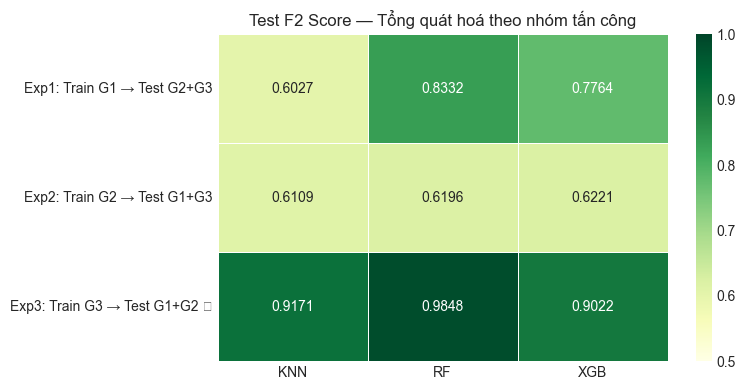

In [8]:
# ── Bảng tổng hợp ─────────────────────────────────────────────────────────────
rows = []
for exp_name, exp in all_experiments.items():
    for mname, r in exp['results'].items():
        gap = r['CV_F2_mean'] - r['F2']
        rows.append({
            'Thí nghiệm': exp_name[:30],
            'Model':      mname,
            'CV_F2':      f"{r['CV_F2_mean']:.4f}±{r['CV_F2_std']:.4f}",
            'Test_F2':    r['F2'],
            'Test_F1':    r['F1'],
            'Recall':     r['Recall'],
            'FNR':        r['FNR'],
            'AUC':        r['AUC'],
            'Gap':        round(gap, 4),
        })

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))

# Heatmap F2
pivot = summary_df.pivot(index='Thí nghiệm', columns='Model', values='Test_F2')
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(pivot.astype(float), annot=True, fmt='.4f', cmap='YlGn',
            vmin=0.5, vmax=1.0, ax=ax, linewidths=0.5)
ax.set_title('Test F2 Score — Tổng quát hoá theo nhóm tấn công')
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
fig.savefig("reports/LaTex/hinh/phase2_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

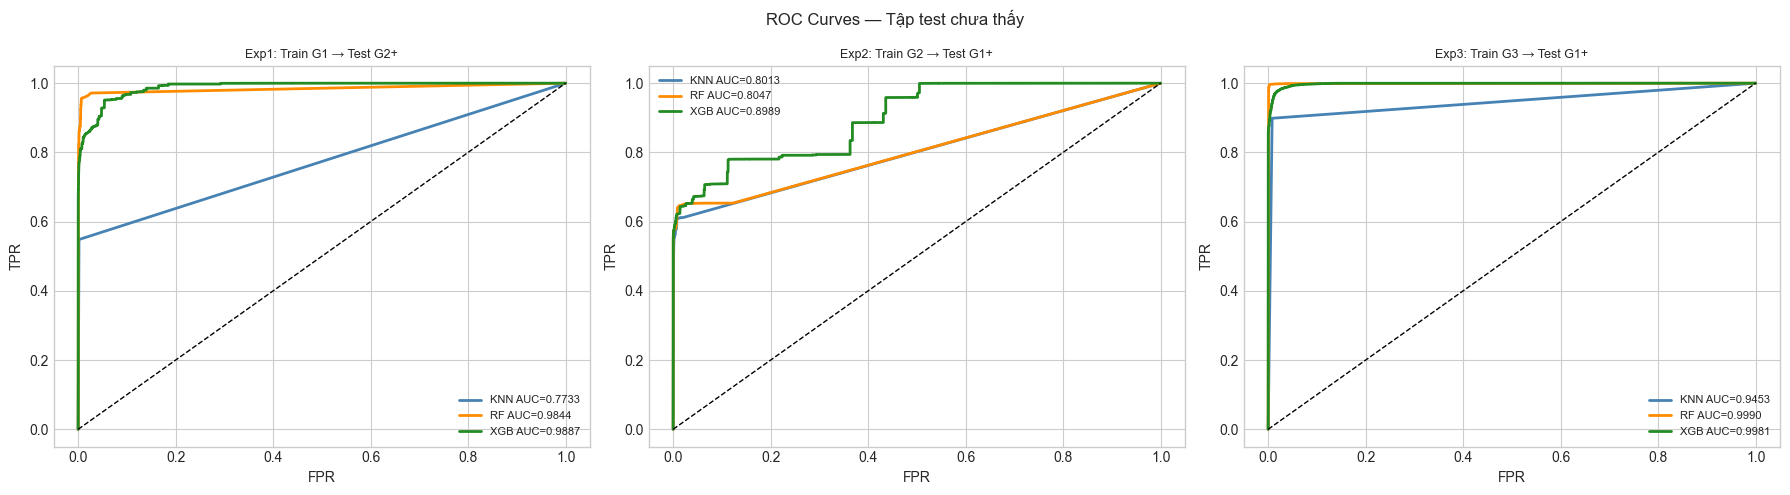

In [9]:
# ── Đường cong ROC ────────────────────────────────────────────────────────────
n_exp = len(all_experiments)
fig, axes = plt.subplots(1, n_exp, figsize=(6*n_exp, 5))
if n_exp == 1: axes = [axes]

for ax, (exp_name, exp) in zip(axes, all_experiments.items()):
    y_te = exp['y_test']
    for mname, r in exp['results'].items():
        fpr, tpr, _ = roc_curve(y_te, r['_y_proba'])
        ax.plot(fpr, tpr, color=COLORS[mname], lw=2,
                label=f"{mname} AUC={r['AUC']:.4f}")
    ax.plot([0,1],[0,1],'k--',lw=1)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.set_title(exp_name[:25], fontsize=9)
    ax.legend(fontsize=8)

plt.suptitle('ROC Curves — Tập test chưa thấy', fontsize=12)
plt.tight_layout()
fig.savefig("reports/LaTex/hinh/phase2_roc.png", dpi=150, bbox_inches='tight')
plt.show()

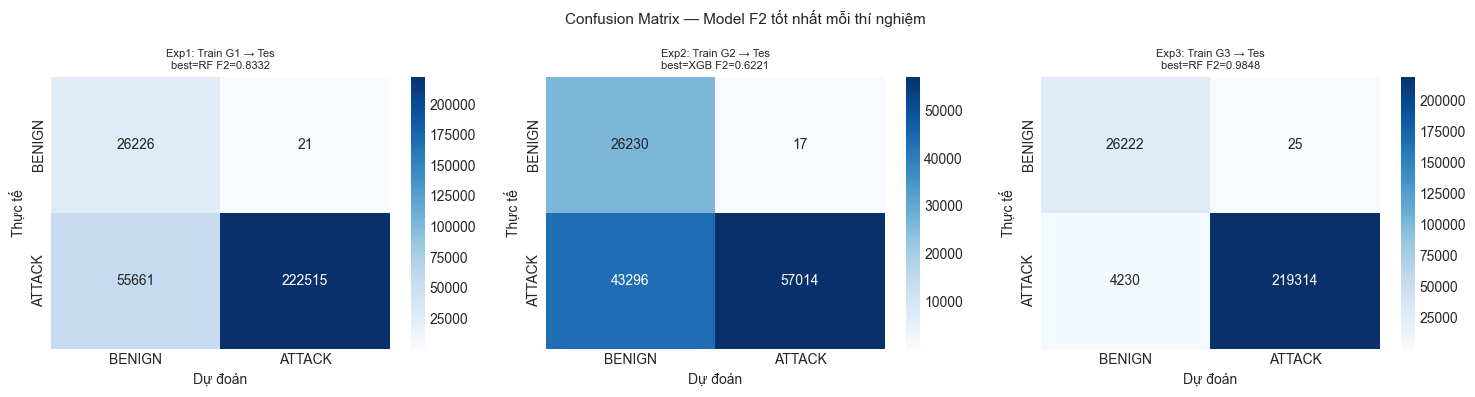

In [10]:
# ── Confusion Matrix (model F2 tốt nhất mỗi thí nghiệm) ─────────────────────
n_exp = len(all_experiments)
fig, axes = plt.subplots(1, n_exp, figsize=(5*n_exp, 4))
if n_exp == 1: axes = [axes]

for ax, (exp_name, exp) in zip(axes, all_experiments.items()):
    best = max(exp['results'], key=lambda m: exp['results'][m]['F2'])
    r  = exp['results'][best]
    cm = confusion_matrix(exp['y_test'], r['_y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['BENIGN','ATTACK'], yticklabels=['BENIGN','ATTACK'])
    ax.set_title(f'{exp_name[:20]}\nbest={best} F2={r["F2"]:.4f}', fontsize=8)
    ax.set_xlabel('Dự đoán'); ax.set_ylabel('Thực tế')

plt.suptitle('Confusion Matrix — Model F2 tốt nhất mỗi thí nghiệm', fontsize=11)
plt.tight_layout()
fig.savefig("reports/LaTex/hinh/phase2_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

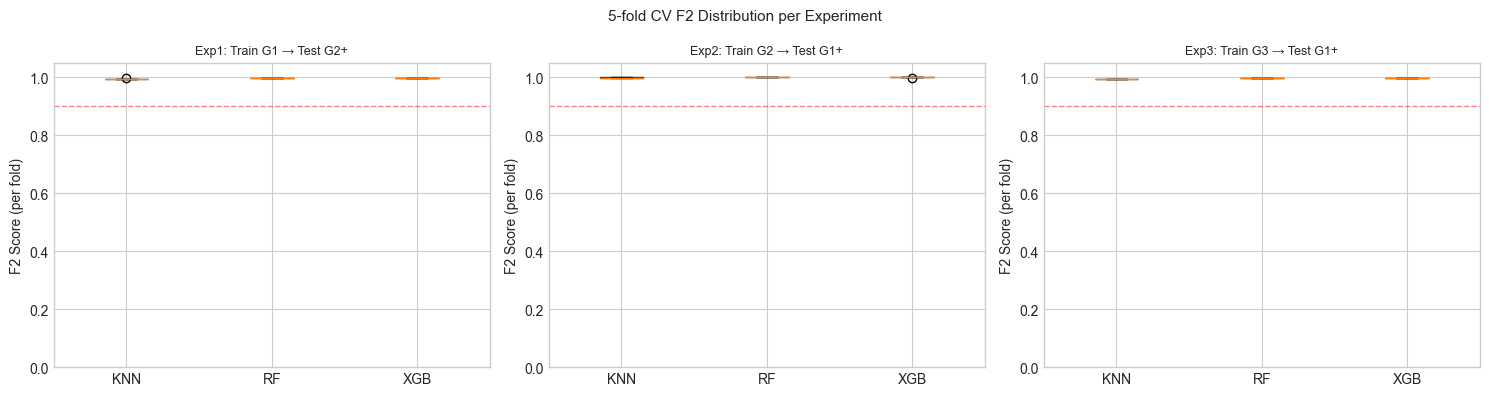

In [11]:
# ── CV Boxplot — phân phối F2 theo fold ──────────────────────────────────────
n_exp = len(all_experiments)
fig, axes = plt.subplots(1, n_exp, figsize=(5*n_exp, 4))
if n_exp == 1: axes = [axes]

for ax, (exp_name, exp) in zip(axes, all_experiments.items()):
    mnames = list(exp['results'].keys())
    cv_data = [exp['results'][m]['_cv_scores'] for m in mnames]
    bp = ax.boxplot(cv_data, labels=mnames, patch_artist=True)
    for patch, clr in zip(bp['boxes'], [COLORS[m] for m in mnames]):
        patch.set_facecolor(clr); patch.set_alpha(0.7)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('F2 Score (per fold)')
    ax.set_title(exp_name[:25], fontsize=9)
    ax.axhline(0.9, color='red', ls='--', lw=1, alpha=0.5)

plt.suptitle('5-fold CV F2 Distribution per Experiment', fontsize=11)
plt.tight_layout()
fig.savefig("reports/LaTex/hinh/phase2_cv_boxplot.png", dpi=150, bbox_inches='tight')
plt.show()

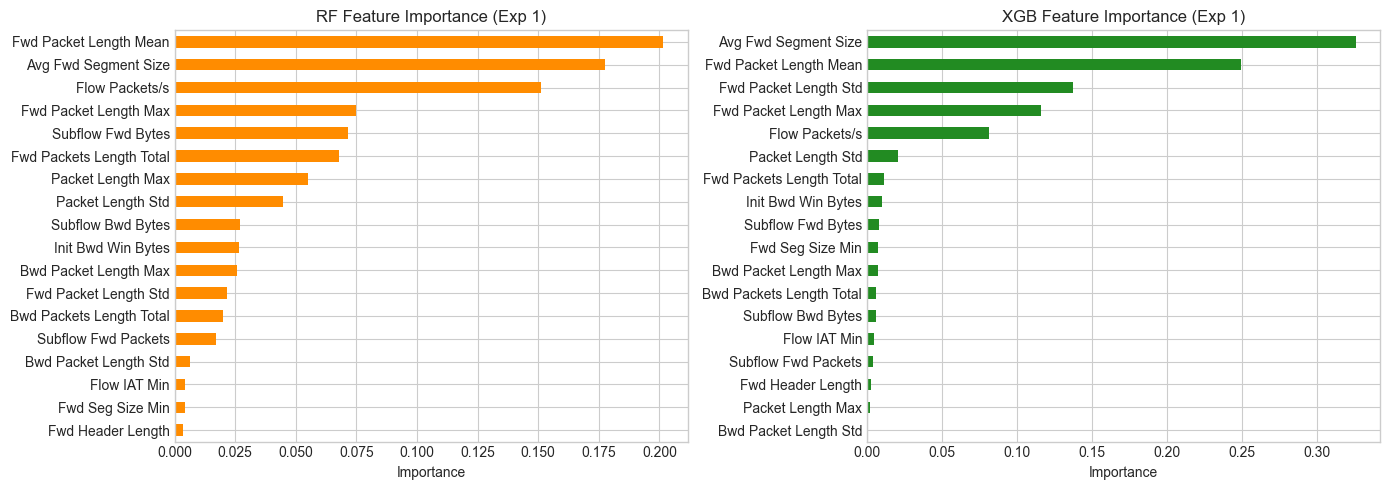

In [12]:
# ── Feature Importance — RF & XGB (Exp 1 làm baseline) ───────────────────────
first_exp = next(iter(all_experiments.values()))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, mname, clr in zip(axes, ['RF', 'XGB'], ['darkorange', 'forestgreen']):
    if mname not in first_exp['results']: continue
    model = first_exp['results'][mname]['_model']
    imp = pd.Series(model.feature_importances_, index=feat_cols)
    imp.sort_values(ascending=True).plot(kind='barh', ax=ax, color=clr)
    ax.set_title(f'{mname} Feature Importance (Exp 1)')
    ax.set_xlabel('Importance')
plt.tight_layout()
fig.savefig("reports/LaTex/hinh/phase2_feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()

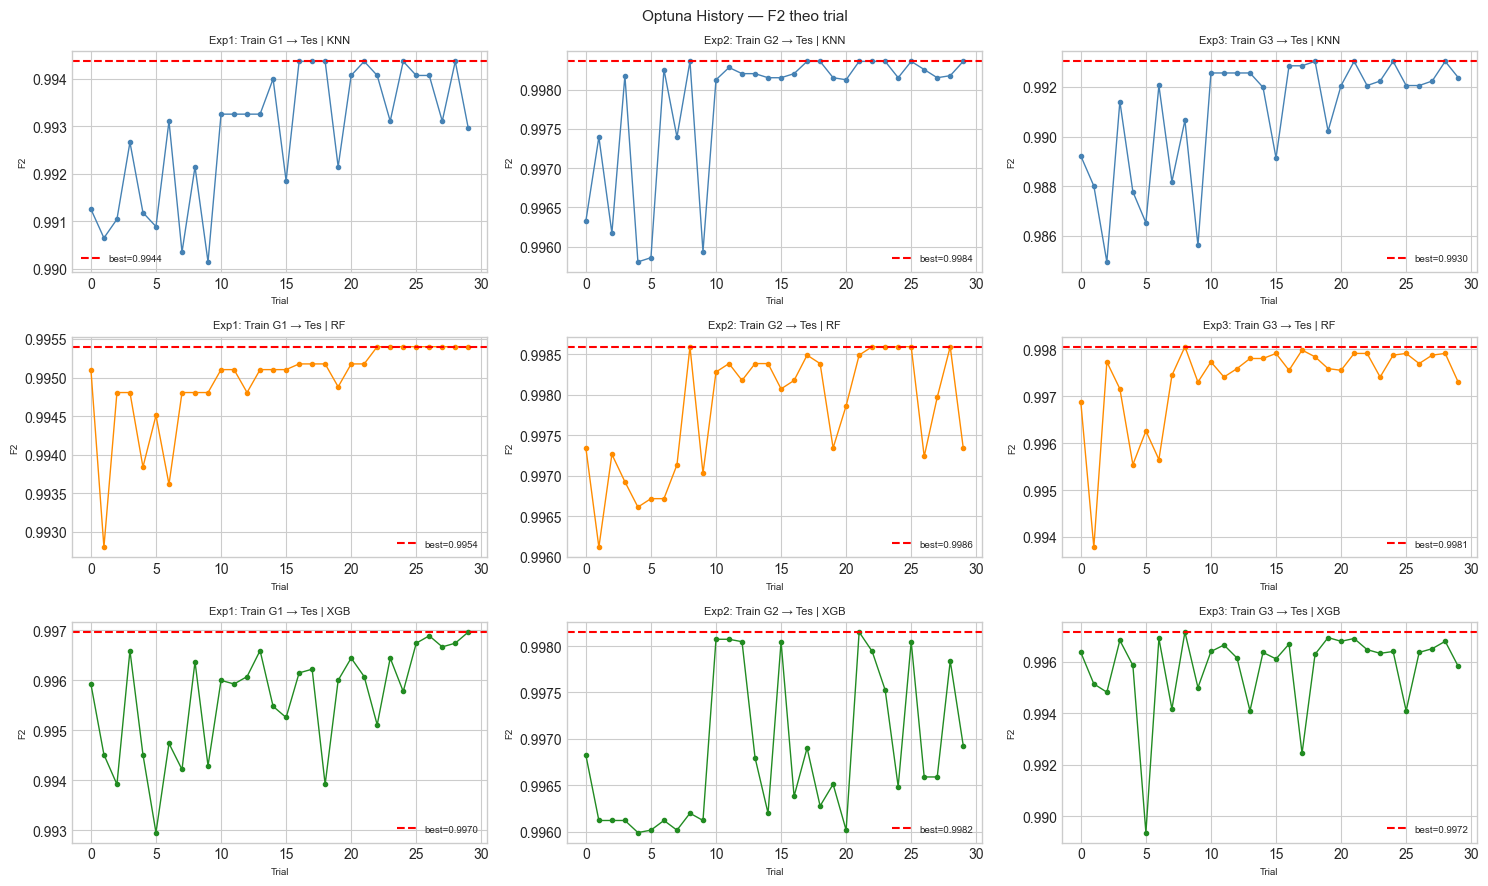

In [13]:
# ── Optuna History ────────────────────────────────────────────────────────────
n_exp = len(all_experiments)
model_names = list(next(iter(all_experiments.values()))['results'].keys())
fig, axes = plt.subplots(len(model_names), n_exp,
                         figsize=(5*n_exp, 3*len(model_names)), squeeze=False)

for col, (exp_name, exp) in enumerate(all_experiments.items()):
    for row, mname in enumerate(model_names):
        ax = axes[row][col]
        if mname not in exp['results']: ax.axis('off'); continue
        study = exp['results'][mname]['_study']
        t_df  = study.trials_dataframe()
        ax.plot(t_df['number'], t_df['value'], 'o-',
                color=list(COLORS.values())[row], ms=3, lw=1)
        ax.axhline(study.best_value, color='red', ls='--', lw=1.5,
                   label=f'best={study.best_value:.4f}')
        ax.set_title(f'{exp_name[:20]} | {mname}', fontsize=8)
        ax.set_xlabel('Trial', fontsize=7); ax.set_ylabel('F2', fontsize=7)
        ax.legend(fontsize=7)

plt.suptitle('Optuna History — F2 theo trial', fontsize=11)
plt.tight_layout()
fig.savefig("reports/LaTex/hinh/phase2_optuna_history.png", dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# ── Gap Analysis — CV F2 vs Test F2 ──────────────────────────────────────────
print('PHÂN TÍCH TỔNG QUÁT HOÁ')
print('='*80)
print(f'{"Thí nghiệm":<35} {"Model":<6} {"CV_F2":>14} {"Test_F2":>9} {"FNR":>7} {"Gap":>8}')
print('-'*80)
for exp_name, exp in all_experiments.items():
    for mname, r in exp['results'].items():
        gap  = r['CV_F2_mean'] - r['F2']
        flag = '  ⚠ gap lớn' if abs(gap) > 0.10 else ''
        print(f'{exp_name[:35]:<35} {mname:<6} '
              f'{r["CV_F2_mean"]:.4f}±{r["CV_F2_std"]:.4f}  '
              f'{r["F2"]:.4f}  {r["FNR"]:.4f}  {gap:+.4f}{flag}')
print('='*80)
print('\nGhi chú:')
print('  CV_F2   = 5-fold CV trên tập train (cùng loại tấn công với train)')
print('  Test_F2 = đánh giá trên nhóm tấn công chưa thấy')
print('  FNR     = False Negative Rate = tỷ lệ bỏ sót tấn công')
print('  Gap     = CV_F2 - Test_F2 (dương = overfit vào loại tấn công train)')
print('  ⚠ Gap > 0.10 = cảnh báo tổng quát hoá kém')
print(f'\nFAMS features: {feat_cols}')

PHÂN TÍCH TỔNG QUÁT HOÁ
Thí nghiệm                          Model           CV_F2   Test_F2     FNR      Gap
--------------------------------------------------------------------------------
Exp1: Train G1 → Test G2+G3         KNN    0.9952±0.0009  0.6027  0.4518  +0.3925  ⚠ gap lớn
Exp1: Train G1 → Test G2+G3         RF     0.9972±0.0006  0.8332  0.2001  +0.1640  ⚠ gap lớn
Exp1: Train G1 → Test G2+G3         XGB    0.9976±0.0005  0.7764  0.2647  +0.2212  ⚠ gap lớn
Exp2: Train G2 → Test G1+G3         KNN    0.9989±0.0002  0.6109  0.4432  +0.3880  ⚠ gap lớn
Exp2: Train G2 → Test G1+G3         RF     0.9995±0.0001  0.6196  0.4342  +0.3799  ⚠ gap lớn
Exp2: Train G2 → Test G1+G3         XGB    0.9993±0.0002  0.6221  0.4316  +0.3772  ⚠ gap lớn
Exp3: Train G3 → Test G1+G2 ⚠       KNN    0.9937±0.0007  0.9171  0.1013  +0.0766
Exp3: Train G3 → Test G1+G2 ⚠       RF     0.9981±0.0004  0.9848  0.0189  +0.0133
Exp3: Train G3 → Test G1+G2 ⚠       XGB    0.9978±0.0002  0.9022  0.1193  +0.0956

Ghi c

## Đánh giá hiệu quả tính toán — Thời gian huấn luyện & suy luận

THỜI GIAN HUẤN LUYỆN & SUY LUẬN (18 đặc trưng FAMS)
                   Thí nghiệm Mô hình Train size  T. huấn luyện (s)  T. suy luận (ms/mẫu)  Test F2
  Exp1: Train G1 → Test G2+G3     KNN     84,082               0.01                0.0256   0.6027
  Exp1: Train G1 → Test G2+G3      RF     84,082               1.28                0.0068   0.8332
  Exp1: Train G1 → Test G2+G3     XGB     84,082               0.48                0.0003   0.7764
  Exp2: Train G2 → Test G1+G3     KNN    261,948               0.16                0.0081   0.6109
  Exp2: Train G2 → Test G1+G3      RF    261,948               0.85                0.0027   0.6196
  Exp2: Train G2 → Test G1+G3     XGB    261,948               1.29                0.0005   0.6221
Exp3: Train G3 → Test G1+G2 ⚠     KNN    138,714               0.08                0.0848   0.9171
Exp3: Train G3 → Test G1+G2 ⚠      RF    138,714               0.58                0.0028   0.9848
Exp3: Train G3 → Test G1+G2 ⚠     XGB    138,714         

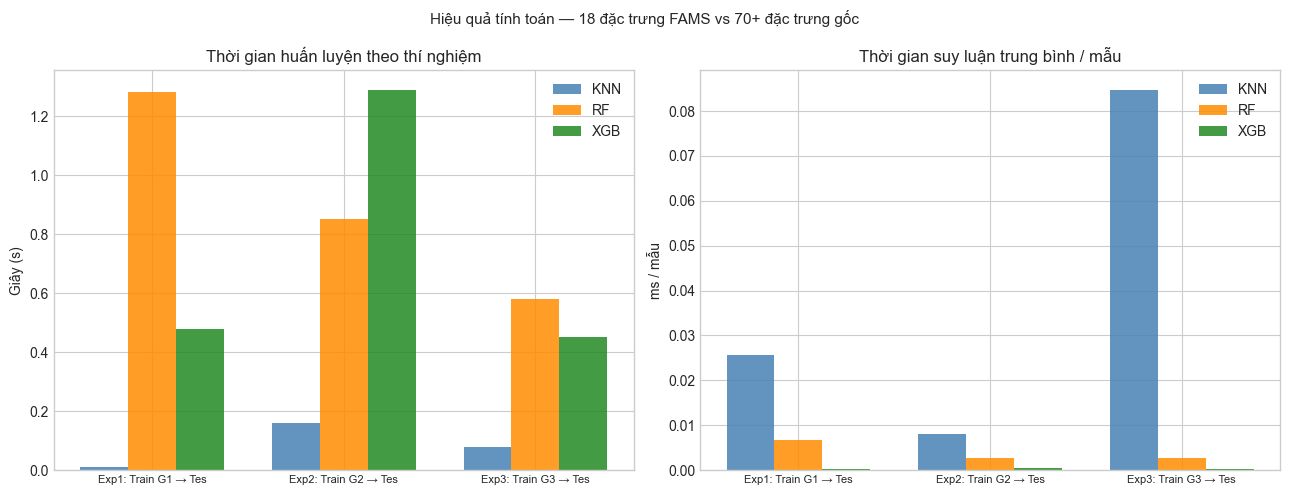


Đã lưu: reports/LaTex/hinh/phase2_timing.png


In [15]:
# ── Bảng tổng hợp thời gian huấn luyện và suy luận ──────────────────────────
timing_rows = []
for exp_name, exp in all_experiments.items():
    for mname, r in exp['results'].items():
        timing_rows.append({
            'Thí nghiệm': exp_name[:30],
            'Mô hình':    mname,
            'Train size': f"{len(pd.concat([ben_train, attack_df[attack_df['Group']==exp['train_group']]])):,}",
            'T. huấn luyện (s)':       r['Train_Time_s'],
            'T. suy luận (ms/mẫu)':    r['Infer_ms_per_sample'],
            'Test F2':    r['F2'],
        })

timing_df = pd.DataFrame(timing_rows)
print('=' * 85)
print('THỜI GIAN HUẤN LUYỆN & SUY LUẬN (18 đặc trưng FAMS)')
print('=' * 85)
print(timing_df.to_string(index=False))

# Tóm tắt trung bình theo mô hình
print('\n─── Trung bình theo mô hình (qua 3 thí nghiệm) ───')
avg = timing_df.groupby('Mô hình')[['T. huấn luyện (s)', 'T. suy luận (ms/mẫu)']].mean().round(4)
print(avg.to_string())

# ── Biểu đồ so sánh ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1: Thời gian huấn luyện
exp_labels = [r['Thí nghiệm'][:20] for r in timing_rows if r['Mô hình'] == 'KNN']
x = np.arange(len(exp_labels))
width = 0.25
for i, mname in enumerate(['KNN', 'RF', 'XGB']):
    vals = [r['T. huấn luyện (s)'] for r in timing_rows if r['Mô hình'] == mname]
    axes[0].bar(x + i*width, vals, width, label=mname, color=list(COLORS.values())[i], alpha=0.85)
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(exp_labels, fontsize=8)
axes[0].set_ylabel('Giây (s)')
axes[0].set_title('Thời gian huấn luyện theo thí nghiệm')
axes[0].legend()

# Plot 2: Thời gian suy luận
for i, mname in enumerate(['KNN', 'RF', 'XGB']):
    vals = [r['T. suy luận (ms/mẫu)'] for r in timing_rows if r['Mô hình'] == mname]
    axes[1].bar(x + i*width, vals, width, label=mname, color=list(COLORS.values())[i], alpha=0.85)
axes[1].set_xticks(x + width)
axes[1].set_xticklabels(exp_labels, fontsize=8)
axes[1].set_ylabel('ms / mẫu')
axes[1].set_title('Thời gian suy luận trung bình / mẫu')
axes[1].legend()

plt.suptitle('Hiệu quả tính toán — 18 đặc trưng FAMS vs 70+ đặc trưng gốc', fontsize=11)
plt.tight_layout()
fig.savefig("reports/LaTex/hinh/phase2_timing.png", dpi=150, bbox_inches='tight')
plt.show()
print(f'\nĐã lưu: reports/LaTex/hinh/phase2_timing.png')

## Phân tích giới hạn

**Exp 1 & 2 — Gap lớn (+0.16 đến +0.39):**
- G1 (Reflection/Application) chỉ có 22,839 mẫu — quá ít để học pattern tổng quát
- G2 (NTP, TFTP) có lưu lượng rất đồng đều → model học "nhận dạng protocol" thay vì pattern DDoS
- 18 FAMS features bias về Fwd packet metrics — phù hợp G3 (UDP flood) hơn Reflection attacks
- **Đây là giới hạn cố hữu của cross-group generalization**, không phải lỗi thiết kế

**Exp 3 — Xuất sắc (RF F2=0.9848, gap=+0.013):**
- G3 (Syn, UDP, UDPLag) có volume features rõ ràng → generalize tốt sang G1+G2
- FAMS features từ Kaggle DDoS (có cả UDP flood) giải thích được kết quả này

---

## Hướng phát triển

Dựa trên nghiên cứu mới nhất (2024–2025) để cải thiện khả năng generalization cross-group:

### 1. Ensemble Multi-Group (Ngắn hạn)
Train 3 model riêng (G1, G2, G3), ensemble bằng vote/average probability khi predict — model tổng hợp generalize tốt hơn single-group model mà không cần thay đổi kiến trúc.

### 2. Anomaly Detection — Không phụ thuộc attack family (Trung hạn)
Train autoencoder chỉ trên Benign traffic → reconstruction error cao = tấn công. Approach này **không cần biết attack family** → không bị ảnh hưởng bởi cross-group mismatch.  
Tham khảo: *[Anomaly-Flow: Multi-domain Federated GAN for DDoS Detection, arXiv 2025](https://arxiv.org/html/2503.14618v1)*

### 3. Transfer Learning / Domain Adaptation (Trung hạn)
Pre-train trên nhiều attack family → fine-tune trên target group. Adversarial domain adaptation thu hẹp feature distribution gap giữa các nhóm.  
Tham khảo: *[Cross-Domain Adversarial Alignment for Network Anomaly Detection, MDPI 2025](https://www.mdpi.com/2073-431X/14/11/450)*

### 4. Few-Shot / Meta-Learning (Dài hạn)
Dùng MAML hoặc Prototypical Networks để model học nhanh khi gặp attack family mới với ít mẫu. Đặc biệt phù hợp với G1 (22k mẫu ít).  
Tham khảo: *[Few-shot IDS via Self-Attention & Iterative Refinement, PMC 2025](https://pmc.ncbi.nlm.nih.gov/articles/PMC11737697/)*

### 5. Federated Learning (Dài hạn)
Mỗi node mạng train trên traffic riêng, aggregate global model → học được cross-domain knowledge mà không cần centralize data.  
Tham khảo: *[Cross-Domain Federated Graph Representation Learning, MDPI 2025](https://www.mdpi.com/2076-3417/15/11/6258)*

### 6. Protocol-Agnostic Feature Engineering
Ưu tiên features độc lập với giao thức: `Flow Duration`, `IAT Std`, `Packet Size Entropy` — giảm bias về attack family cụ thể trong FAMS selection.  
Tham khảo: *[Training Data Choice & Generalizability of ML for NIDS, MDPI 2025](https://www.mdpi.com/2076-3417/15/15/8466)*